In [5]:
%load_ext autoreload
%autoreload
import os, copy, h5py
import astropy.units as u
from astropy.cosmology import Planck13, z_at_value
import numpy as np
import pandas as pd
from syntheticstellarpopconvolve import convolve, default_convolution_config, default_convolution_instruction
from syntheticstellarpopconvolve.general_functions import generate_boilerplate_outputfile, extract_unit_dict, temp_dir
from compas_python_utils.cosmic_integration.ClassCOMPAS import COMPASData
from syntheticstellarpopconvolve.starformation_rate_distributions import starformation_rate_distribution_vanSon2023, madau_dickinson_sfr
from syntheticstellarpopconvolve.metallicity_distributions import metallicity_distribution_vanSon2022, compas_log_skew_normal_distribution_metallicity_distribution
from syntheticstellarpopconvolve.general_functions import calculate_bincenters, calculate_bin_edges
from syntheticstellarpopconvolve.cosmology_utils import lookback_time_to_redshift
from syntheticstellarpopconvolve.SFR_dict_plotting_routines import plot_sfr_dict
import matplotlib.pyplot as plt
import time
import warnings
import scipy
from scipy import stats
from get_ZdepSFRD import skew_metallicity_distribution, Madau_Dickinson2014
from population_vis import get_formation_efficiency

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


1 binary in COMPAS represents 79.11015055714887  solar masses formed
20000000
1582203011.1429775  [Msun]
ClassCOMPAS: Remember to self.setCOMPASDCOmask()
                    then self.setCOMPASData()
          and optionally self.setGridAndMassEvolved() if using a metallicity grid


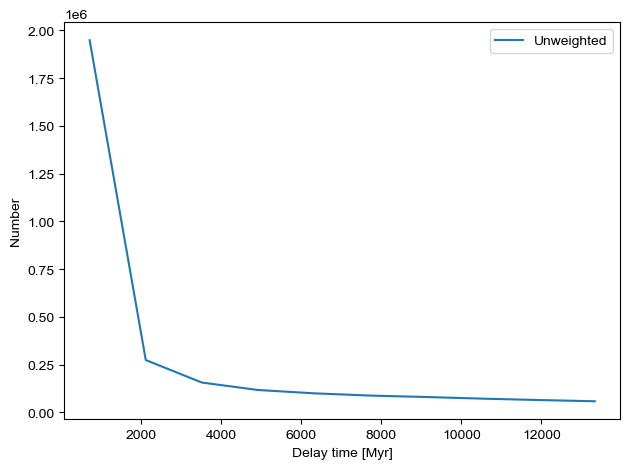

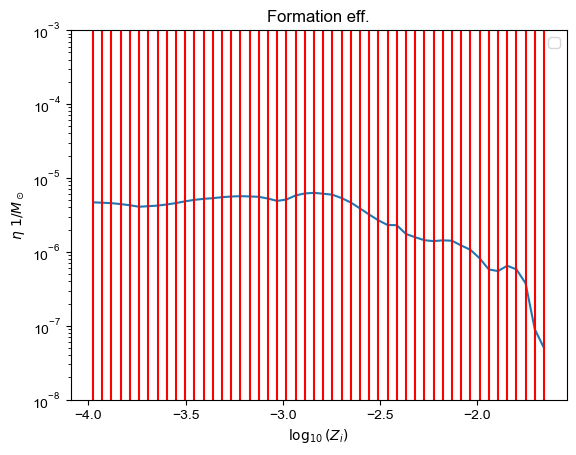

In [6]:
filepath = '/Volumes/Elements/Boesky_alpha0.1beta0.5.h5'

# SET UP DATA -- from a basic dict, port to an h5 file and then store this into the output file
# now we want to use some real data
fdata = h5py.File(filepath)
all_dco_seeds = fdata['BSE_Double_Compact_Objects']['SEED'][()]
all_seeds = fdata['BSE_System_Parameters']['SEED'][()]
metallicities = fdata["BSE_System_Parameters"]["Metallicity@ZAMS(1)"][()]
# potentially mask with/without a stable mass transfer or without an envelope
mixture_weight = fdata["BSE_System_Parameters"]["mixture_weight"][()]
fdata.close()
TYPES = 'BBH'
fe_binned, fe_bins, compasdata = get_formation_efficiency(filepath, types=TYPES)
delayTimes = compasdata.delayTimes

# need to get the metallicities as well
dco_query = np.isin(all_seeds, all_dco_seeds[compasdata.DCOmask])
dco_metallicities = metallicities[dco_query]
dco_mixture_weight = mixture_weight[dco_query]
assert len(delayTimes[()]) == len(dco_metallicities), "Something went wrong with masking for dco metallicities"
# to query the probabilties, we can digitize the fe_kde using the dco metallicities
# or just use the kde directly -- TODO: maybe one way is more true than the other?
# start_time = time.time()
# #dco_efficiencies = fe_kde(dco_metallicities) # this is WAY too slow, have to use bins
# dfe_logZ = np.digitize(np.log10(dco_metallicities), (fe_bins[:-1]+fe_bins[1:])/2) - 1
# dco_efficiencies = fe_binned[dfe_logZ]
# print(f'Took {time.time() - start_time} to find efficiencies')
plt.rcParams['font.family'] = 'Arial'

In [12]:
from shared import get_all_snr_weights, networks
det_choice = 'LV_O4a'
snr = 8
# all_snr_weights = get_all_snr_weights(
#     networks[det_choice]['array'],
#     networks[det_choice]['snr'],
#     dco_metallicities,
#     TYPES
# )
# we will export this as is because that is easier to do for now, should also make switching
# sens's in the large plot code
# np.save(f'{TYPES}_{det_choice}_{networks[det_choice]['snr']}.npy', all_snr_weights)
all_snr_weights = np.load(f'{TYPES}_{det_choice}_{snr}.npy')

[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5]
sum from weights is: 3884.6762404078813
comvng vol: 345.39527984413917
Complete sum is 195252.32507186968
0.7057416567147682
comvng vol: 345.39527984413917
Complete sum is 81743.65113411569
comvng vol: 515.5797759888501
Complete sum is 457033.3822212387
0.38489695602043944
comvng vol: 515.5797759888501
Complete sum is 39331.53950219819
comvng vol: 519.2248320867011
Complete sum is 450030.9131618892
0.19064344643399786
comvng vol: 519.2248320867011
Complete sum is 5823.88854082642
comvng vol: 477.38189756214956
Complete sum is 275582.30228297383
0.09274887717909396
comvng vol: 477.38189756214956
Complete sum is 498.3144035839132
comvng vol: 428.54856492754766
Complete sum is 141463.23028144604
0.04578357806609458
comvng vol: 428.54856492754766
Complete sum is 42.92565835717075
comvng vol: 383.1251918537414
Complete sum is 70132.55268004534
0.023157811476958636
comvng vol: 383.1251918537414
Complete sum is 5.23642860

/var/folders/xf/4xjcxwsx60s4g6c1mw4np0z40000gn/T/ipykernel_15622/2351901095.py:113: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  form_fig.show()


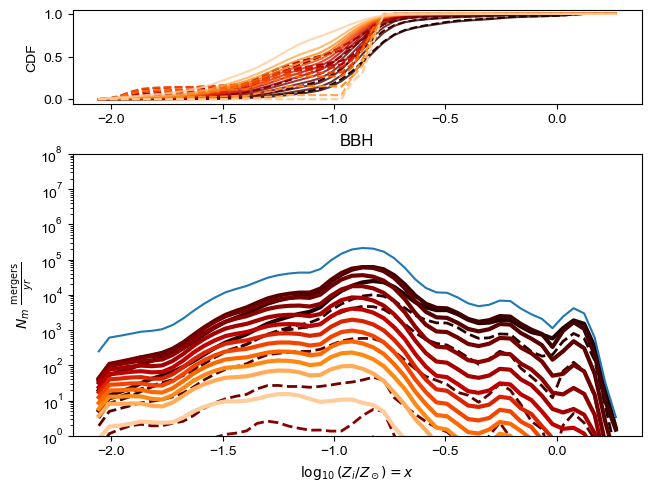

In [13]:
# basically same plot as above, but now we want to bin by redshift basically 
# form_fig, form_ax = plt.subplots(1, 1)
form_fig = plt.figure(constrained_layout=True)
form_ax = form_fig.subplot_mosaic(
    [
        ['Top'],
        ['Bottom']
    ], gridspec_kw={'height_ratios': [1,3]}
)
PLOT_Z_LOG = True
Zm = np.log10(dco_metallicities/0.012) if PLOT_Z_LOG else dco_metallicities/0.012

import pickle
from shared import plot_merger_rate_from_hdf_file
fiducial_plotting_data = plot_merger_rate_from_hdf_file(
    '/Volumes/Elements/test.h5',
    'output_data/growl/intrinsic/convolution_results/',
    dco_metallicities
)

fiducial_plotting_data['Zm'] = Zm
fiducial_plotting_data['types'] = TYPES
with open(f'fiducial_{TYPES}.pkl', 'wb') as p:
    pickle.dump(fiducial_plotting_data, p)

all_weights = fiducial_plotting_data['all_weights']
redshifts = fiducial_plotting_data['redshifts']
print(redshifts)
# sum up to z
# redshift_edges = np.array([0, 1, 2, 3, 5, 10])#np.linspace(0, 14, 5)#np.logspace(np.log10(0.001), np.log10(14), 5)
redshift_edges = redshifts#np.array([0, 2, 5, 10])
def do_metallicity_plot_to_redshift(left, right, color, with_SNR=False, draw_CDF=False, with_label=True):
    z_left = np.digitize(left, redshifts)
    z_right = np.digitize(right, redshifts)
    assert z_left >= 0 and z_right >= 0, "Bad redshift bin query"

    weights = np.sum(all_weights[:, z_left:z_right], axis=1)
    snr = 1
    if with_SNR:
        snr_block = all_snr_weights[z_left:z_right,:]
        snr = np.sum(snr_block)/(snr_block.shape[1]*snr_block.shape[0])
        print(snr)
        divisor = snr_block.shape[0]
        weights *= np.sum(snr_block,axis=0)/(snr_block.shape[0]) if divisor > 0 else 0
    
    if np.allclose(weights,0) or np.sum(np.isnan(weights))>0:
        null_bins = np.linspace(np.min(Zm), np.max(Zm), 50)
        return null_bins, np.zeros_like(null_bins)
    dco_met_hist, dco_met_bins = np.histogram(
        Zm,
        weights=weights,
        bins=50,
        density=True
    )

    dco_met_bins_midpoints = (dco_met_bins[:-1]+dco_met_bins[1:])/2
    dlogZ = np.diff(dco_met_bins)
    # print(f'Sum is {dco_metallicity_weighted_kde(dco_met_bins_midpoints)@dlogZ}')

    # normalize by using comoving shell
    Vleft = Planck13.comoving_volume(left).to(u.Gpc**3).value
    Vright = Planck13.comoving_volume(right).to(u.Gpc**3).value
    comoving_volume = Vright - Vleft
    print(f'comvng vol: {comoving_volume}')

    # plot_line = dco_metallicity_weighted_kde(dco_met_bins_midpoints)*dlogZ*np.sum(weights)*comoving_volume#*snr
    plot_line = dco_met_hist*dlogZ*np.sum(weights)*comoving_volume*snr
    print(f'Complete sum is {np.sum(plot_line)}')
    lab = f'z:[{left},{right}]'
    if with_label:
        form_ax['Bottom'].plot(dco_met_bins_midpoints, plot_line, label=lab, color=color, linewidth=2 if with_SNR else 3, linestyle = '--' if with_SNR else 'solid')
    else:
        form_ax['Bottom'].plot(dco_met_bins_midpoints, plot_line, color=color, linewidth=2 if with_SNR else 3, linestyle = '--' if with_SNR else 'solid')
    # form_ax.fill_between(dco_met_bins_midpoints, plot_line, alpha=0.3)

    # cdf_ax = form_ax.twinx()
    if draw_CDF:
        form_ax['Top'].plot(dco_met_bins_midpoints, np.cumsum(plot_line/np.sum(plot_line)), label=f'{lab} CDF', linestyle = '--' if with_SNR else 'solid', color=color, alpha=1 if with_SNR else 0.8) #, linewidth=2 if with_SNR else 3
    # cdf_ax.tick_params(axis='y', labelcolor='red')
    # cdf_ax.set_yscale('log')
    # form_ax.axhline(plot_line.max())
    return dco_met_bins_midpoints, plot_line

print(f'sum from weights is: {np.sum(fiducial_plotting_data['all_weights'])}')

color_bins = plt.cm.gist_heat(np.linspace(0.1, 0.9, len(redshift_edges)-1))
alt_color_bins = plt.cm.Greens(np.linspace(0.3, 0.9, len(redshift_edges)-1))

# zm_bins, _ = do_metallicity_plot_to_redshift(0, 10, 'green')
zm_bins, intrinsic_start = do_metallicity_plot_to_redshift(redshift_edges[0], redshift_edges[1], color_bins[0], draw_CDF=True)
sum_total = intrinsic_start
do_metallicity_plot_to_redshift(redshift_edges[0], redshift_edges[1], color_bins[0], with_SNR=True, with_label=False, draw_CDF=True)

for i in range(1, len(redshift_edges)-1):
    _, intrinsic_line = do_metallicity_plot_to_redshift(redshift_edges[i], redshift_edges[i+1], color_bins[i], draw_CDF=True)
    sum_total = sum_total + intrinsic_line
    do_metallicity_plot_to_redshift(redshift_edges[i], redshift_edges[i+1], color_bins[i], with_SNR=True, with_label=False, draw_CDF=True)
form_ax['Bottom'].plot(zm_bins, sum_total, label='Sum total')
# assert np.allclose(sum_total, total_plot), "intrinsic sum fail"
# do_metallicity_plot_to_redshift(0, 5, 'red')
# do_metallicity_plot_to_redshift(0, 5, 'green', with_SNR=True)

form_ax['Bottom'].set_xlabel(r'$\log_{10}(Z_i/Z_\odot)=x$' if PLOT_Z_LOG else r'$Z_i/Z_\odot=x$')

# form_ax.set_ylabel(r'$dN(x)*\int_{z_1}^{z_2} dz \frac{dR_m}{dz}$')
form_ax['Bottom'].set_ylabel(r'$N_m~\frac{\text{mergers}}{yr}$')
form_ax['Bottom'].set_yscale('log')
form_ax['Bottom'].set_title(f'{TYPES}')
form_ax['Bottom'].set_ylim(1, 1e8)
# form_ax['Bottom'].legend()
form_ax['Top'].set_ylabel('CDF')
# form_ax['SNR'].set_ylabel('With SNR CDF')
form_fig.show()